# Project 2

### Group members

Tereza Bílková (7137257), Bela F. Brunner (8002193), Niels Epema (2927578), Adam Zich (0074187).

## Utility functions for both analytic and computatinal part

In [1110]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [1111]:
# Path for saving figures

PATH = str(Path.cwd().parent) + '/tex/figures/'

In [1112]:
# Initial physical constants

T = 0.1 # Oscilation period (s)
omega = 2 * np.pi / T # Angular frequency (rad/s)
rho = 1000 # Fluid density (kg/m^3)
mu = 1 # Dynamic viscosity (N*s/m^2)
nu = mu / rho # Kinematic viscosity (m^2/s)
U0 = 1 # horizontal plate velocity amplitude (m/s)

In [1113]:
# Function that generates an equally spaced array of values based on minimum, maximum and step size

def generate_quantity_array(q_min, q_max, dq):
    num_points = int((q_max - q_min) / dq) + 1
    return np.linspace(q_min, q_max, num_points)

In [1114]:
# Function that generates representative points for line plots

def get_representative_points(quantity, num_points, percentage_range = [0, 1]):
    return np.linspace(int(len(quantity) * percentage_range[0]), int(len(quantity) * percentage_range[1] - 1), num_points).astype(int)

In [1115]:
# Plotting functions

def contour_plot(z, t, u):
    plt.figure(figsize=(10, 6))
    plt.contourf(t, z, u, levels=50, cmap='seismic')
    plt.colorbar(label='Velocity (m/s)')
    plt.xlabel('Time (s)')
    plt.ylabel('Height (m)')
    plt.title('Velocity Contour Plot')
    plt.show()

def line_plot(x, u, representative_points, rep_point_values, x_label, rep_point_name, rows=True, title='Velocity', save=False, filename='', sublabel=['']):
    plt.figure(figsize=(10, 6))
    for j in range(len(u)):
        for i in range(len(representative_points)):
            if rows:
                plt.plot(x, u[j][representative_points[i]], label=f'{rep_point_name} {sublabel[j]} = {rep_point_values[representative_points[i]]:.3f} m')
            else:
                plt.plot(u[j][:, representative_points[i]], x, label=f'{rep_point_name} {sublabel[j]} = {rep_point_values[representative_points[i]]:.3f} s')
    if rows:
        plt.xlabel(x_label)
        plt.ylabel('Velocity (m/s)')
    else:
        plt.xlabel('Velocity (m/s)')
        plt.ylabel(x_label)
    plt.title(f'{title} profiles at Representative {rep_point_name} points')
    plt.legend()
    plt.grid()
    if save:
        plt.savefig(PATH + filename)
    plt.show()

## Analytic part

### e)

In [1116]:
# Additional constants for the analytic part

k = np.sqrt(omega / (2 * nu)) # Wavenumber (1/m)

# tau function out of the analytic part d)
def tau(z):
    return k * z / omega

In [1117]:
# Velocity field

def velocity_field(z, t):
    return U0 * np.exp(-1 * k * z) * np.sin(2 * np.pi * ((t - tau(z) / T)))

In [ ]:
# Constants for plotting the velocity field

# Height parameters
dz = 0.0005 # spatial step (m)
z_min = 0 # minimum height (m)
z_max = 0.1 # maximum height (m)
z = generate_quantity_array(z_min, z_max, dz) # height array

# Time paramteres
dt = T/4 # time step (s)
t_min = 0 # start time (s)
t_max = T/4 # end time (s)
t = generate_quantity_array(t_min, t_max, dt) # time array

# Velocity array
u_analytic = np.transpose([velocity_field(z, 0), velocity_field(z, T/4)])  # velocity field at t = 0 and t = T/4

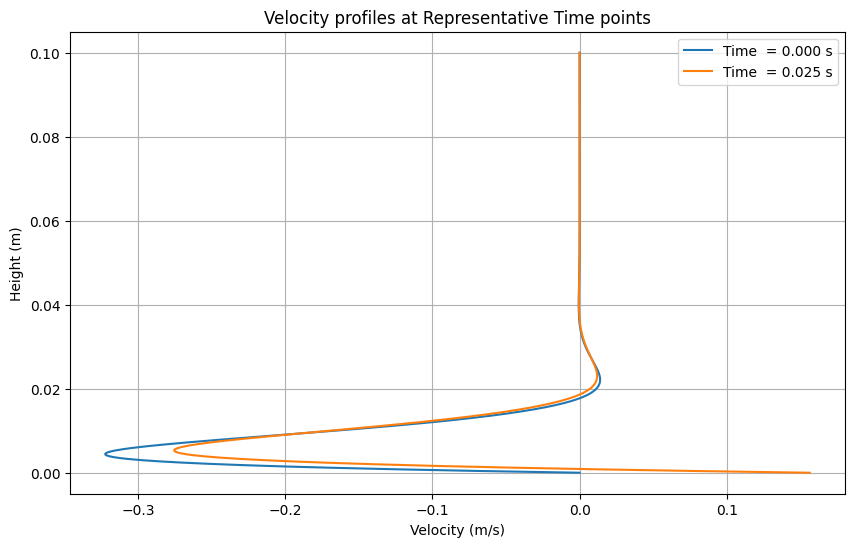

In [1119]:
# Plot the velocity field at t = 0 and t = T/4

number_of_representative_points = 2
t_representative_points = get_representative_points(t, number_of_representative_points)
line_plot(z, [u_analytic], t_representative_points, t, 'Height (m)', 'Time', rows=False, save=False, filename="1_e_Velocity_profile_t=0.png") # Actual velocity profile

## Computational part

In [1120]:
# Velocity function of the horizontal plate at z = 0

def plate_velocity(t):
    return U0 * np.sin(omega * t)

### a) Geometry

We saw in e) in the plot that we created that the damping is already significant for z=0.06. Therefore, ar reasonable value for H could be 0.1.

### b)

A reasonable approach for the step size is normally $1/100$ of the initial value. We found experimentally that $1/200$ also works well, therefore we use in this case $dz=0.1/200=5 * 10^{-4}$.

In [1121]:
# Compute diffusion

# Function to approximate the second vertical derivative using central difference
def second_vertical_derivative(u, dz):
    return (u[2:] + u[:-2] - 2 * u[1:-1]) / dz**2

# Function to compute the right-hand side of the diffusion equation
def F_RHS(u, dz):
    return nu * second_vertical_derivative(u, dz)

# Function to compute the diffusion equation using an explicit time-stepping method
def diffusion_equation(u, dz, dt, t, velocity_function):
    return np.append(np.append([velocity_function(t)], u[1:-1] + dt * F_RHS(u, dz)), 0)

# Function to iteratively apply the diffusion equation for a given number of time steps
def iterative_diffusion(u, dz, dt, N_t, velocity_function=plate_velocity):
    for t in range(1, N_t):
        u.append(diffusion_equation(u[t-1], dz, dt, t * dt, velocity_function))
    return u

### c)

Based on the results above a good value for dt given the period T is one that follows the the equation dt < dz^2/(2\nu/\rho) and does not make the computational time too large. Additionally, the numnber of time steps that should be chosen is N<sub>t</sub> = (t_max - t_min) / dt, so that the whole esired time range is covered. The function defined here is executed within d).

In [1]:
# Function to compute the minimum time step or spatial step for stability
    
def get_minimum_step(d, nu, time=True):
    if time:
        return (d**2 / (2 * nu)) * 0.99
    else:
        return (np.sqrt(2 * nu * d)) * 1.01


### d)

#### d) - plots

In [ ]:
# Constants for plotting of figures 1), 2) and 3) in both d) and e)

# Height parameters
dz = 0.0005 # spatial step (m)
z_min = 0 # minimum height (m)
z_max = 0.1 # maximum height (m)
z = generate_quantity_array(z_min, z_max, dz) # height array

# Time parameters
dt = get_minimum_step(dz, nu, time=True) * 0.2 # time step (s) that satisfies the stability condition
t_min = 0 # start time (s)
t_max = 2 # end time (s)
N_t = int((t_max - t_min) / dt) + 1 # number of time steps
t = generate_quantity_array(t_min, t_max, dt) # time array

# Velocity array
u = np.transpose(iterative_diffusion([np.append([plate_velocity(0)], np.zeros((1, len(z) - 1)))], dz, dt, N_t)) # velocity array (m/s) with initial condition u(z, t=0) = 0 for z > 0 and u(z=0, t) = plate_velocity(t)

##### 1) Contour plot of u(t, z)

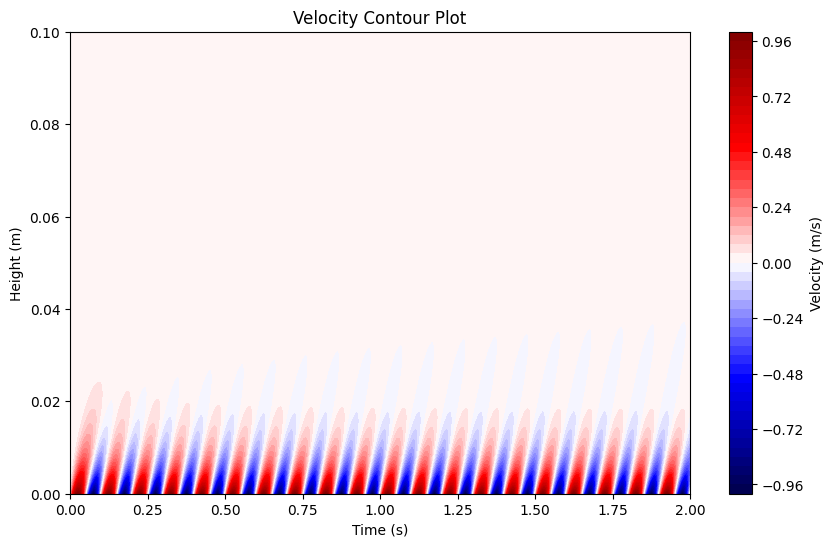

In [ ]:
# Plot 1)

contour_plot(z, t, u)

##### 2) Line plot of velocity against time at representative heights

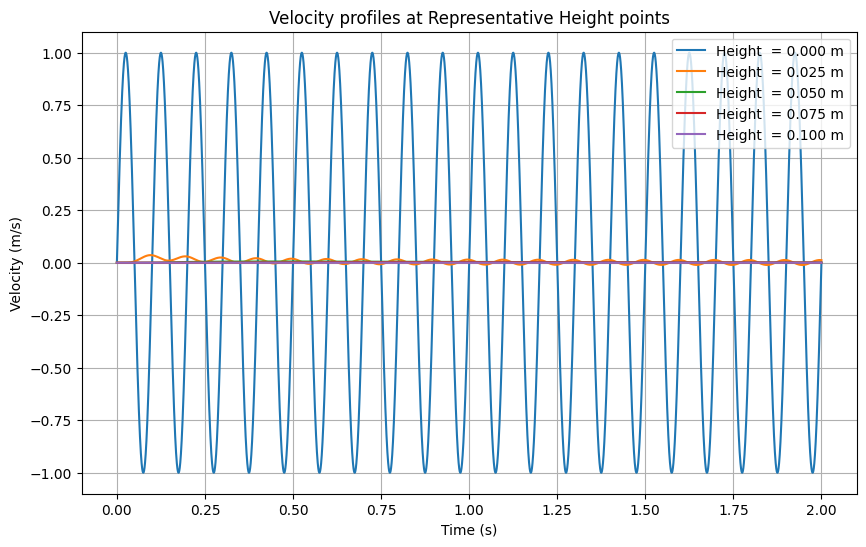

In [ ]:
# Plot 2)

number_of_representative_points = 5
z_representative_points = get_representative_points(z, number_of_representative_points)
line_plot(t, [u], z_representative_points, z, 'Time (s)', 'Height')

##### 3) Line plot of velocity against height at representative times

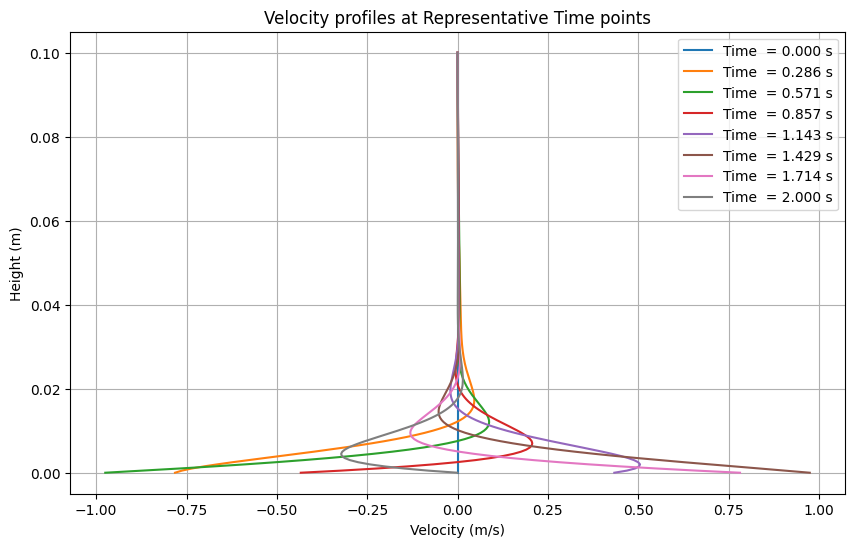

In [ ]:
# Plot 3)

number_of_representative_points = 8
t_representative_points = get_representative_points(t, number_of_representative_points)
line_plot(z, [u], t_representative_points, t, 'Height (m)', 'Time', rows=False) # Actual velocity profile

#### d) - subquestions

Based on our plots, we see that the upper bound H does not cut off the velocity in a strange way but is far enough that the velocity goes to zero naturally by that point. Our value for dt and dz is also small enough as we do not see any artefacts in the plots.

It takes approximately 10 periods, or 1 second, before the effect of starting up is gone. We approximated this by looking at the velocity profiles in d).

Once the start-up effect is gone our numerical result compares very well compared with the analytical reuslt. As you can see in the plots belowe, before the startup period has ened, the velocity profiles differ between the theoretical and numerical results. In the second plot, however, after the startup period has ended they overlap to the point where they are indistinguishable in the plot.

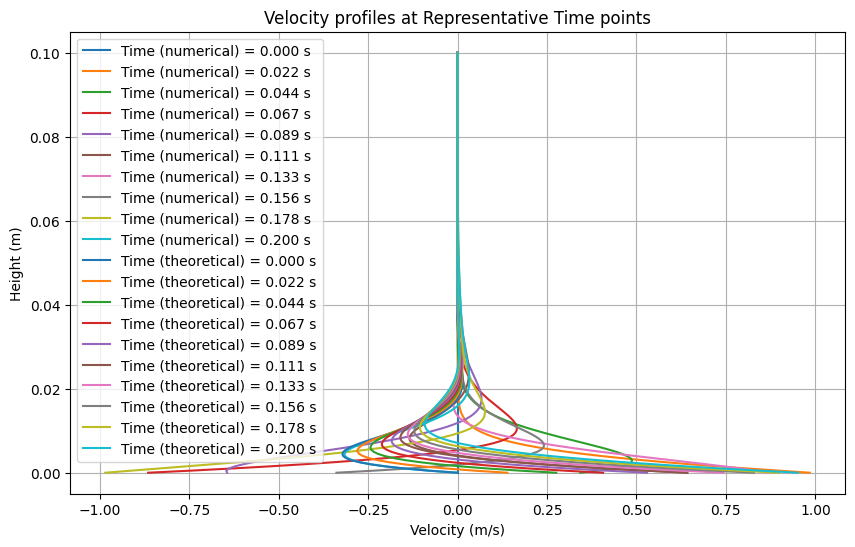

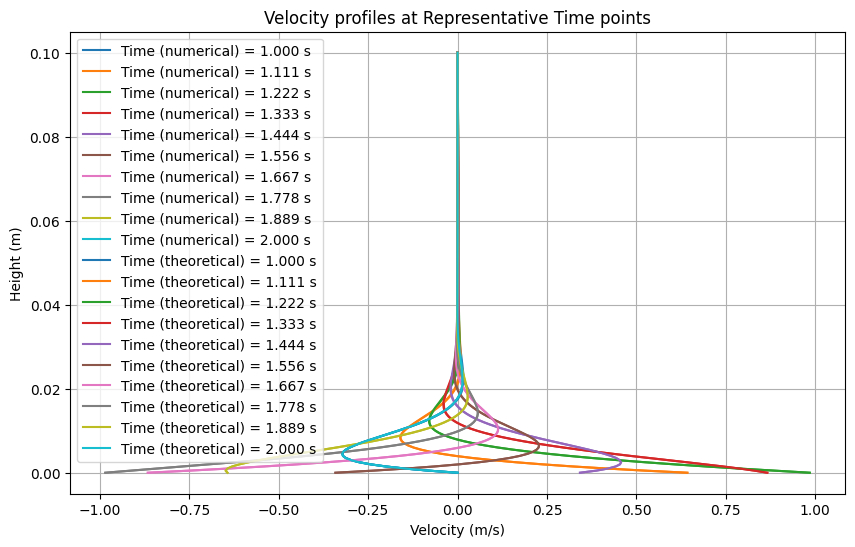

In [ ]:
# Comparison of analytical and computational result

number_of_representative_points = 10
t_startup_representative_points = get_representative_points(t, number_of_representative_points, [0, 0.1]) # time interval from t_min to 0.1 * t_max
t_representative_points = get_representative_points(t, number_of_representative_points, [0.5, 1]) # time interval from 0.5 * t_min to t_max
u_a = []
for time in t:
    u_a.append(velocity_field(z, time))
u_a = np.transpose(u_a)
line_plot(z, [u, u_a], t_startup_representative_points, t, 'Height (m)', 'Time', rows=False, save=False, filename="1_e_Velocity_profile_t=0.png", sublabel=['(numerical)', '(theoretical)']) # Actual velocity profile """
line_plot(z, [u, u_a], t_representative_points, t, 'Height (m)', 'Time', rows=False, save=False, filename="1_e_Velocity_profile_t=0.png", sublabel=['(numerical)', '(theoretical)']) # Actual velocity profile """

### e)

In [ ]:
# New constants

T_2 = T/2 # Oscillation period (s)

In [ ]:
# New velocity function of the horizontal plate at z = 0

def plate_velocity_2(t):
    positive = -2 * (np.floor(t / T_2) % 2)
    return U0 * (1 + positive)

#### e) - plots

In [ ]:
# Change relevant constants for plotting of figures 1), 2) and 3) in e)

u_e = np.transpose(iterative_diffusion([np.append([plate_velocity_2(0)], np.zeros((1, len(z) - 1)))], dz, dt, N_t, velocity_function=plate_velocity_2)) # velocity array (m/s) with initial condition u(z, t=0) = 0 for z > 0 and u(z=0, t) = plate_velocity_2(t)

##### 1) Contour plot of u(t, z)

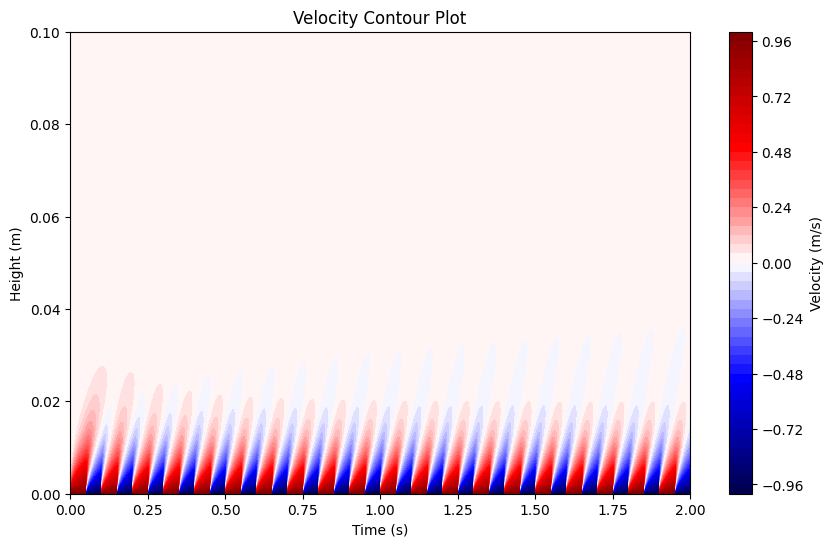

In [ ]:
# Plot 1)

contour_plot(z, t, u_e)

##### 2) Line plot of velocity against time at representative heights

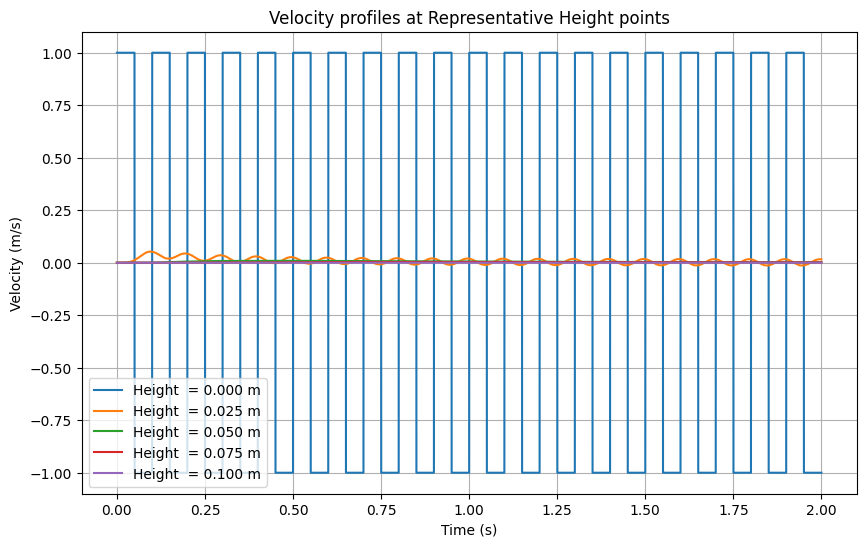

In [ ]:
# Plot 2)

number_of_representative_points = 5
z_representative_points = get_representative_points(z, number_of_representative_points)
line_plot(t, [u_e], z_representative_points, z, 'Time (s)', 'Height')

##### 3) Line plot of velocity against height at representative times

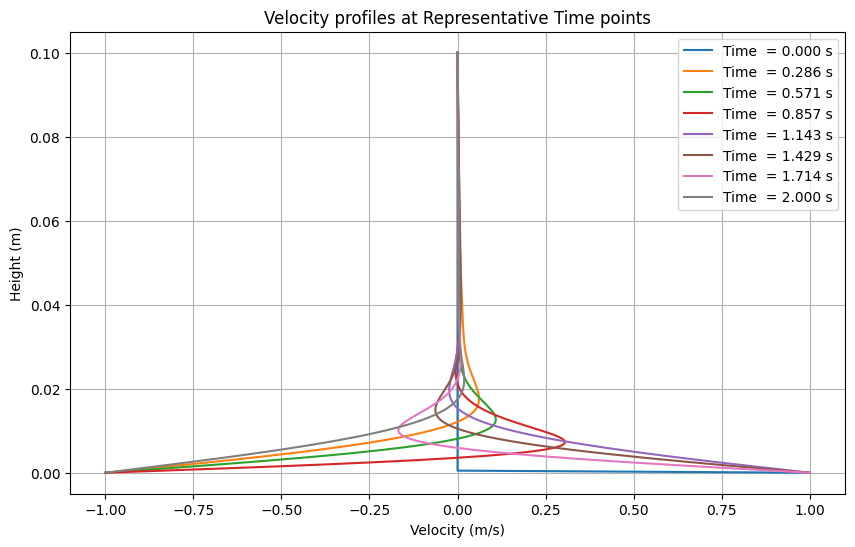

In [ ]:
# Plot 3)

number_of_representative_points = 8
t_representative_points = get_representative_points(t, number_of_representative_points)
line_plot(z, [u_e], t_representative_points, t, 'Height (m)', 'Time', rows=False) # Actual velocity profile

#### e) - subquestion

In coparison with the plots in d) we can see that the startup is very sharp as the plate imeediately moves at velocity U. We, however, do not observe a relevant difference in velocity profiles other than directly at the plate or very close to it. This is because for the plate in e) it jump straigt to U or -U wheras the velocity function in d) gradually builds up to it.

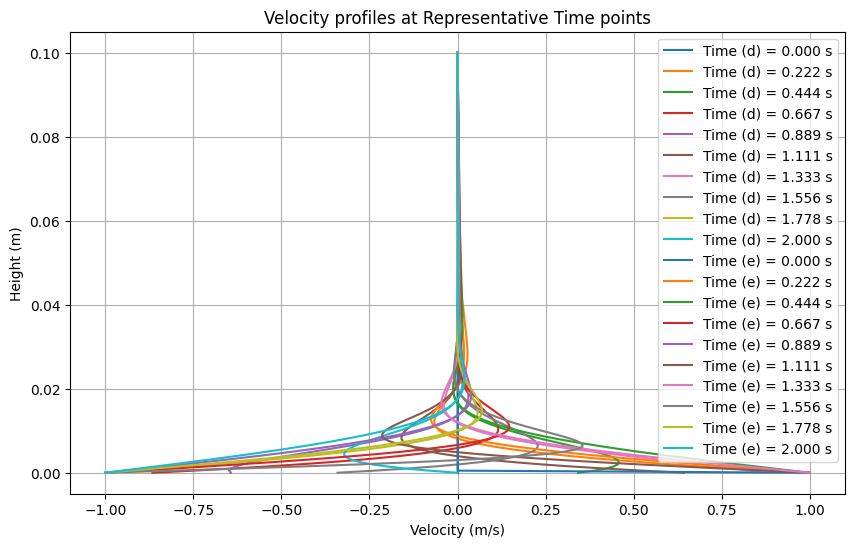

In [ ]:
# Comparison of velocity profiles

number_of_representative_points = 10
t_representative_points = get_representative_points(t, number_of_representative_points)
line_plot(z, [u, u_e], t_representative_points, t, 'Height (m)', 'Time', rows=False, sublabel=['(d)', '(e)'])